# Adjust transfroms for good Dataloading of Topspin Dataset

The create-sequence funciton is now available in event_representations

In [1]:
import os
import sys
import torch
sys.path.append("../src/")
sys.path.append("../src/models/")
sys.path.append("../src/data/")
sys.path.append("../src/data/components/")
sys.path.append("../src/utils/")
import event_represenations
from TOPSPIN import Hdf5Dataset

import numpy as np
from torchvision import transforms
import tonic
import matplotlib.pyplot as plt

/home/lkolmar/anaconda3/envs/learning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
test_ds = tonic.datasets.NMNIST(save_to="../data/NMNIST", train=False)
test_sample = test_ds[0][0]

In [3]:

indices = np.arange(100)
trans = transforms.Compose([
    # lambda ev: event_represenations.events_to_voxel(ev["x"], ev["y"], ev["t"], ev["p"], num_bins=20, sensor_size=(100, 100)),  # create voxel grid from events
    # lambda x: x.reshape(4, 5, 34, 34)
])

dataset = Hdf5Dataset("/data/lkolmar/datasets/topspin_fit_to_max/", indices, trans)

print(indices)
print(dataset[0][0])
sample = dataset[0][0]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
[(12, 32,    203, 1) (67, 41,    249, 0) (25, 83,    251, 1) ...
 (85, 75, 195675, 0) (57, 80, 195675, 0) (74, 59, 195676, 1)]


In [4]:
print(test_sample)
print(f"Max_x: {test_sample['x'].max()}, Min_x: {test_sample['x'].min()}")
print(f"Max_y: {test_sample['y'].max()}, Min_y: {test_sample['y'].min()}")
print(f"Max_t: {test_sample['t'].max()}, Min_t: {test_sample['t'].min()}")
print(f"Max_p: {test_sample['p'].max()}, Min_p: {test_sample['p'].min()}")

[(18, 11,    581, 0) (21, 13,   1703, 0) (12, 24,   2625, 0) ...
 (21, 19, 307025, 1) (32, 10, 307397, 1) (10, 19, 308529, 1)]
Max_x: 33, Min_x: 0
Max_y: 33, Min_y: 0
Max_t: 308529, Min_t: 581
Max_p: 1, Min_p: 0


In [5]:
print(sample)
print(f"Max_x: {sample['x'].max()}, Min_x: {sample['x'].min()}")
print(f"Max_y: {sample['y'].max()}, Min_y: {sample['y'].min()}")
print(f"Max_t: {sample['t'].max()}, Min_t: {sample['t'].min()}")
print(f"Max_p: {sample['p'].max()}, Min_p: {sample['p'].min()}")
print(f"Event count: {sample['x'].shape[0]}")

[(12, 32,    203, 1) (67, 41,    249, 0) (25, 83,    251, 1) ...
 (85, 75, 195675, 0) (57, 80, 195675, 0) (74, 59, 195676, 1)]
Max_x: 99, Min_x: 0
Max_y: 99, Min_y: 1
Max_t: 195676, Min_t: 203
Max_p: 1, Min_p: 0
Event count: 1017727


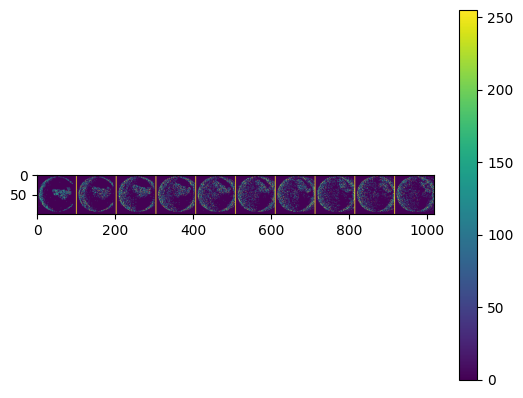

In [11]:
voxel = event_represenations.events_to_voxel(sample["x"], sample["y"], sample["t"], sample["p"], num_bins=500, sensor_size=(100, 100))
plt.imshow(event_represenations.get_voxel_grid_as_image(voxel[:10]))
plt.colorbar()
plt.show()

In [23]:
trans = transforms.Compose([
    lambda ev: event_represenations.events_to_voxel(ev["x"], ev["y"], ev["t"], ev["p"], num_bins=10, sensor_size=(100, 100)),  # create voxel grid from events
    # lambda x: x.reshape(4, 5, 34, 34)
])
sample = dataset[0][0]

time_window = 5000 
def create_sequence(events, time_window=500, num_bins=10, sensor_size=(100, 100)):
    start_time = events['t'][0]
    end_time = events['t'][-1]

    # Vectorized version using numpy
    t = events['t']
    # Compute the bin index for each event
    bin_indices = ((t - start_time) // time_window).astype(int)
    num_frames = ((end_time - start_time) // time_window) + 1
    sequences = np.zeros((num_frames, num_bins, sensor_size[0], sensor_size[1]), dtype=np.float32)

    for i in range(num_frames):
        mask = bin_indices == i
        seq = events[mask]
        if len(seq) > 0:
            sequences[i] = event_represenations.events_to_voxel(seq['x'], seq['y'], seq['t'], seq['p'], num_bins=num_bins, sensor_size=sensor_size)

    return sequences

sequences = create_sequence(sample, time_window=time_window)
print(f"Number of sequences: {len(sequences)}")


Number of sequences: 40


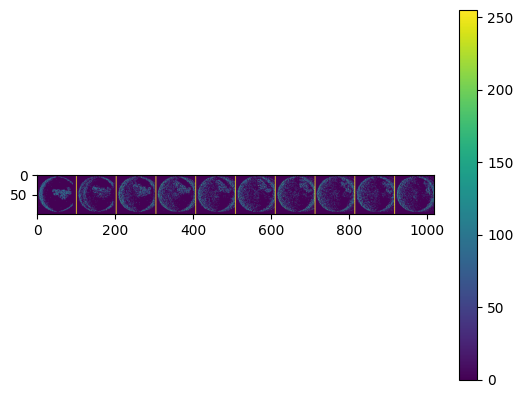

In [25]:
voxel = sequences[0]
plt.imshow(event_represenations.get_voxel_grid_as_image(voxel[:10]))
plt.colorbar()
plt.show()

In [27]:
trans = transforms.Compose([
    lambda ev: create_sequence(ev, time_window=time_window, num_bins=10, sensor_size=(100, 100)),  # create sequences from events
    # lambda x: x.reshape(4, 5, 34, 34)
])
sample = dataset[0][0]
sample = trans(sample)
print(sample.shape)


(40, 10, 100, 100)
